In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
print("Libraries imported successfully")

Libraries imported successfully


In [7]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [8]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df_model = df.copy()
cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

In [10]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [11]:
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.81      1409



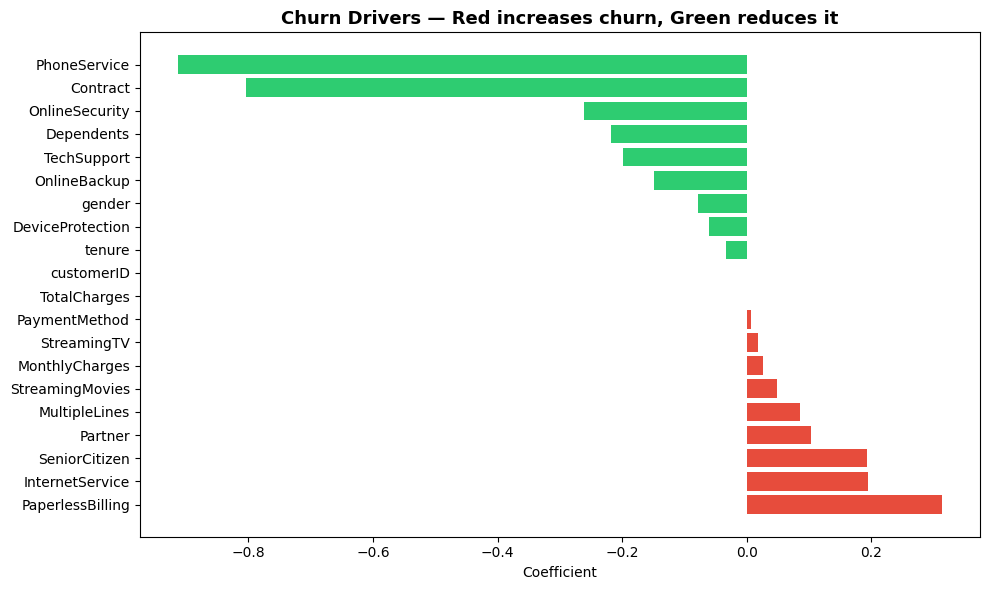

In [12]:
import numpy as np

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'], color=colors)
plt.title('Churn Drivers — Red increases churn, Green reduces it', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('churn_drivers.png', dpi=150)
plt.show()

In [13]:
from google.colab import files

df_export = df.copy()
df_export['Churn'] = df_export['Churn'].map({1: 'Yes', 0: 'No'})
df_export.to_csv('churn_cleaned.csv', index=False)
files.download('churn_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_2788/801018414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])


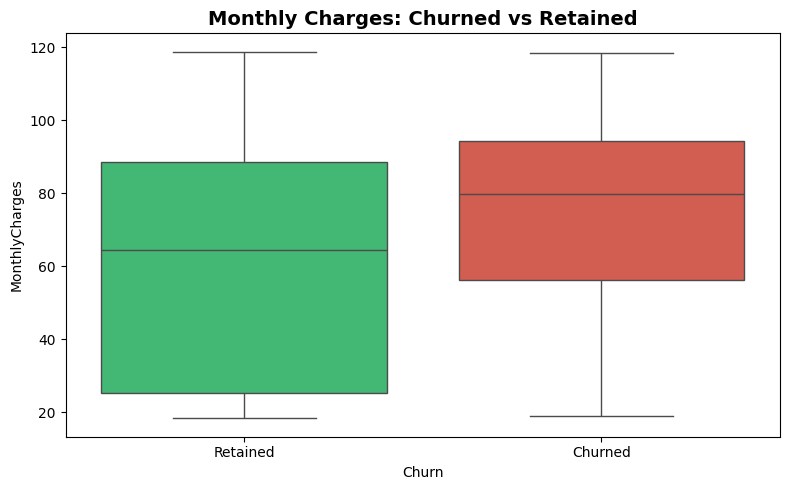

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges: Churned vs Retained', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Retained', 'Churned'])
plt.tight_layout()
plt.savefig('charges_vs_churn.png', dpi=150)
plt.show()

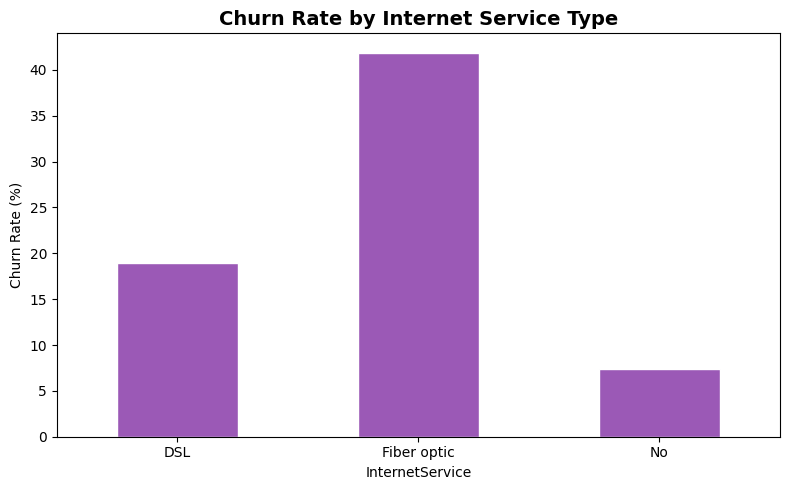

In [16]:
df['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})
internet_churn = df.groupby('InternetService')['Churn_numeric'].mean() * 100
plt.figure(figsize=(8,5))
internet_churn.plot(kind='bar', color='#9b59b6', edgecolor='white')
plt.title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_internet.png', dpi=150)
plt.show()

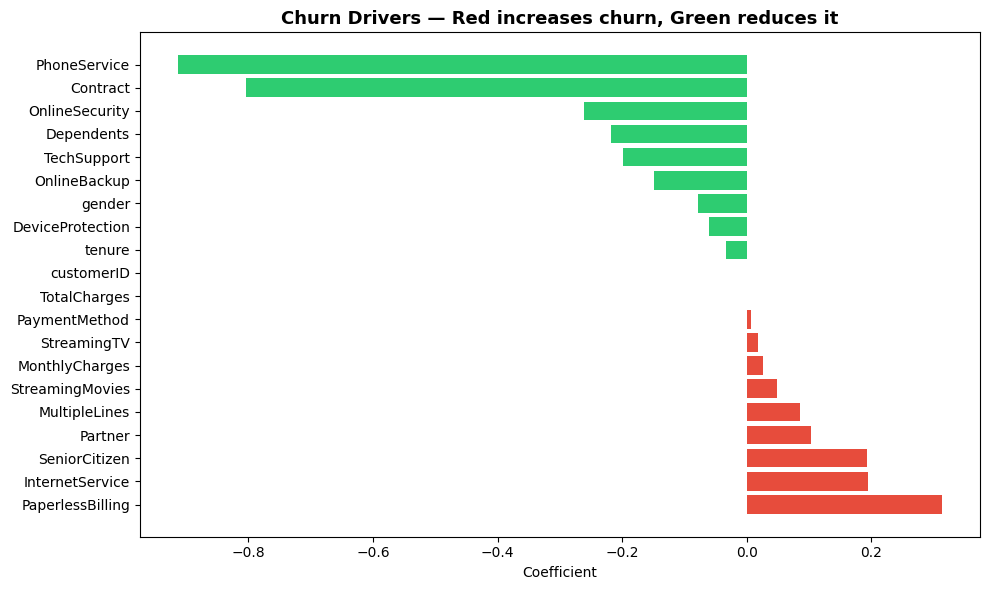

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'], color=colors)
plt.title('Churn Drivers — Red increases churn, Green reduces it', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('churn_drivers.png', dpi=150)
plt.show()

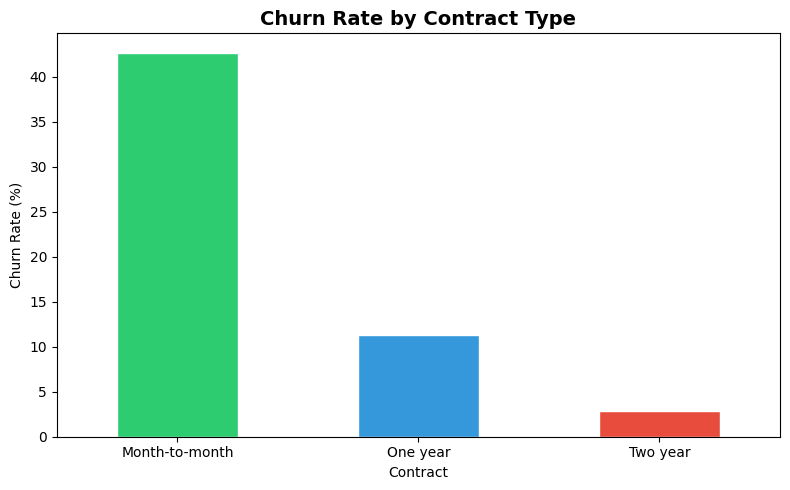

In [19]:
contract_churn = df.groupby('Contract')['Churn_numeric'].mean() * 100
plt.figure(figsize=(8,5))
contract_churn.plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c'], edgecolor='white')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

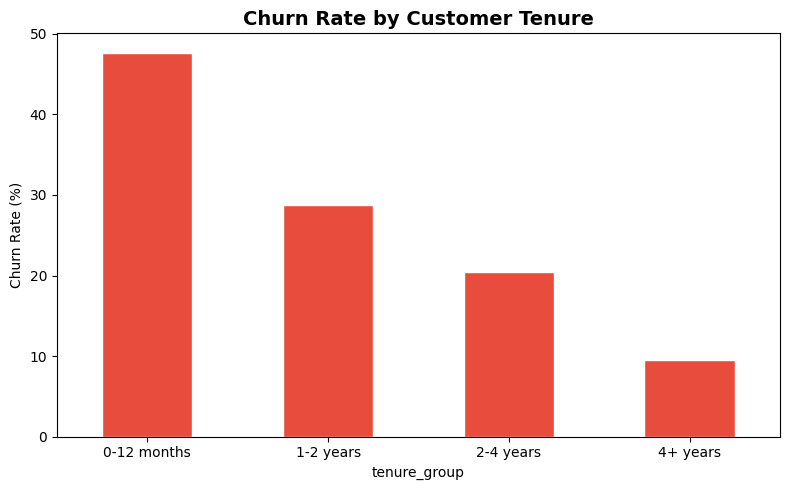

In [25]:
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '1-2 years', '2-4 years', '4+ years'])

tenure_churn = df.groupby('tenure_group', observed=True)['Churn_numeric'].mean() * 100
plt.figure(figsize=(8,5))
tenure_churn.plot(kind='bar', color='#e74c3c', edgecolor='white')
plt.title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()

In [23]:
import os
files = ['churn_by_contract.png', 'churn_by_tenure.png',
         'charges_vs_churn.png', 'churn_by_internet.png', 'churn_drivers.png']

for f in files:
    print(f, '✅' if os.path.exists(f) else '❌ MISSING')

churn_by_contract.png ✅
churn_by_tenure.png ✅
charges_vs_churn.png ✅
churn_by_internet.png ✅
churn_drivers.png ✅
